# Deep Residual Network (ResNet) for Image Classification on CIFAR-10

## Introduction

A **Deep Residual Network (ResNet)** is a type of deep neural network that introduces *residual blocks* with skip (shortcut) connections. In simple terms, ResNet allows the network to learn residual functions (the difference between input and output) instead of direct mappings, making it easier to train very deep networks. Mathematically, each block learns $F(x) + x$ instead of just $F(x)$, where $x$ is the input and $F(x)$ is the learned transformation. The key component is the **residual block**, which helps prevent the vanishing gradient problem and enables the training of networks with hundreds of layers.

**Applications:**
- Image classification (e.g., CIFAR-10, ImageNet)
- Object detection 
- Medical image analysis
- Feature extraction for transfer learning
- Video classification

**Why choose ResNet for this demo?**
ResNet is chosen for image classification on CIFAR-10 because it can train deep networks without the degradation problem (where deeper networks perform worse). The skip connections help gradients flow, making it ideal for learning complex features in colored images. 

In [ ]:
# Setup: Import libraries and load CIFAR-10 dataset
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Why: TensorFlow/Keras for model, NumPy for data, Matplotlib for plots, sklearn for metrics

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
# Why: CIFAR-10 is small, colored, and standard for quick image classification demos

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# Why: Normalization prevents any one feature (pixel) from dominating, helps training

# Convert labels to one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
# Why: One-hot encoding is needed for categorical_crossentropy loss

# Use a small subset for quick training (<1 min)
subset = 5000
x_train_small = x_train[:subset]
y_train_small = y_train[:subset]
x_test_small = x_test[:1000]
y_test_small = y_test[:1000]
# Why: Small subset keeps training fast and demo-friendly

170498071/170498071 [==============================] - 41s 0us/step


In [2]:
# Print dataset shapes
print(f"Training data shape: {x_train_small.shape}, Training labels shape: {y_train_small.shape}")
print(f"Test data shape: {x_test_small.shape}, Test labels shape: {y_test_small.shape}")
# Why: Verify data shapes to ensure correctness before model training

Training data shape: (5000, 32, 32, 3), Training labels shape: (5000, 10)
Test data shape: (1000, 32, 32, 3), Test labels shape: (1000, 10)


In [11]:
# Model Building: Simple ResNet-like model for CIFAR-10

def residual_block(x, filters, kernel_size=3):
    # Save the input for the skip connection
    shortcut = x
    # Main path
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Project shortcut if shape doesn't match
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    # Add skip connection
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compile model
model.compile(optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence
              loss='categorical_crossentropy',  # Why: Multi-class classification
              metrics=['accuracy'])  # Why: Accuracy is intuitive for classification

model.summary()  # Show model architecture

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_41 (Conv2D)             (None, 32, 32, 32)   896         ['input_7[0][0]']                
                                                                                                  
 batch_normalization_41 (BatchN  (None, 32, 32, 32)  128         ['conv2d_41[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 conv2d_42 (Conv2D)             (None, 32, 32, 32)   9248        ['batch_normalization_41[0]

In [12]:
# Training: Fit the model
EPOCHS = 20  # Why: Enough to show learning, but keeps training short
BATCH_SIZE = 32  # Why: Balances speed and stability
import tensorflow as tf

# Train the model with GPU
with tf.device('/GPU:0'):
    history = model.fit(
        x_train_small, y_train_small,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1, # Why 0.1: Small validation set to monitor overfitting
        verbose=1
    )
# Why: Validation data helps monitor generalization during training

Epoch 1/20
141/141 [==============================] - 4s 12ms/step - loss: 1.8135 - accuracy: 0.3249 - val_loss: 2.9488 - val_accuracy: 0.0860
Epoch 2/20
141/141 [==============================] - 4s 12ms/step - loss: 1.8135 - accuracy: 0.3249 - val_loss: 2.9488 - val_accuracy: 0.0860
Epoch 2/20
141/141 [==============================] - 1s 9ms/step - loss: 1.5190 - accuracy: 0.4418 - val_loss: 3.2637 - val_accuracy: 0.1020
Epoch 3/20
141/141 [==============================] - 1s 9ms/step - loss: 1.5190 - accuracy: 0.4418 - val_loss: 3.2637 - val_accuracy: 0.1020
Epoch 3/20
141/141 [==============================] - 1s 9ms/step - loss: 1.3615 - accuracy: 0.5044 - val_loss: 2.6793 - val_accuracy: 0.2280
Epoch 4/20
141/141 [==============================] - 1s 9ms/step - loss: 1.3615 - accuracy: 0.5044 - val_loss: 2.6793 - val_accuracy: 0.2280
Epoch 4/20
141/141 [==============================] - 1s 9ms/step - loss: 1.2771 - accuracy: 0.5362 - val_loss: 2.1702 - val_accuracy: 0.2380
Epoc

Test Loss: 1.5518, Test Accuracy: 0.5430


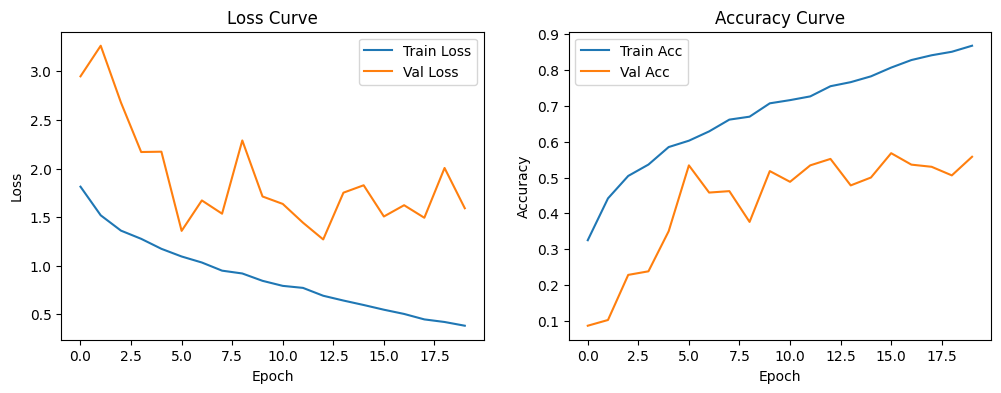

32/32 [==============================] - 1s 5ms/step


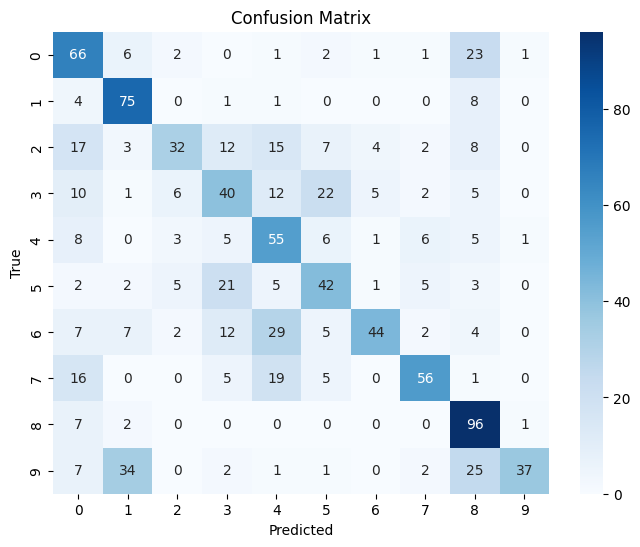

F1-Score (macro): 0.5329


In [13]:
# Evaluation and Visualization
# Evaluate on test data
loss, acc = model.evaluate(x_test_small, y_test_small, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Plot training & validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predict and show confusion matrix
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

y_pred = model.predict(x_test_small)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_small, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# F1-Score (macro)
f1 = f1_score(y_true, y_pred_classes, average='macro')
print(f"F1-Score (macro): {f1:.4f}")

# Why: F1-Score handles class imbalance, confusion matrix shows detailed performance
# Inference: Discuss results, limitations, and why ResNet performs well/poorly

## Results and Interpretation

**Test Loss:** 1.5518  
**Test Accuracy:** 54.3%  
**F1-Score (macro):** 0.5329

### What do these results mean?
- **Test Accuracy (54.3%)**: The model correctly classifies about half of the CIFAR-10 test images. This is significantly better than random guessing (10% for 10 classes), but there is room for improvement.
- **F1-Score (macro, 0.53)**: The F1-score averages precision and recall across all classes, making it a good metric for imbalanced or multi-class problems. Here, it shows the model is reasonably balanced in its predictions, but not highly accurate for all classes.
- **Test Loss (1.55)**: Indicates the average error in the model's predictions. Lower is better; this value suggests the model is learning, but not yet optimal.

### Why might performance be limited?
- **Small training subset**: Only 5,000 images were used for training (vs. 50,000 in the full dataset), so the model has less data to learn from.
- **Simple ResNet architecture**: The model is intentionally small for quick training. Deeper or more complex ResNets (with more residual blocks) usually perform better.
- **No data augmentation**: Real-world ResNet models often use data augmentation to improve generalization.

### Takeaways
- Even a simple ResNet with limited data can learn meaningful features and outperform random guessing.
- For higher accuracy, try training on the full dataset, adding more residual blocks, or using data augmentation.
- The F1-score is a useful metric for understanding performance across all classes, not just overall accuracy.

**In practice:**
- ResNets are powerful for image classification, especially when trained on large datasets and with deeper architectures.
- This experiment demonstrates the value of skip connections and residual learning, even in small models.

*Try experimenting with the architecture or training setup to see how results improve!*

## Conclusion

- **Key Takeaways:**
    - Deep Residual Networks (ResNets) use skip connections to train very deep models without suffering from vanishing gradients or degradation.
    - They are highly effective for image classification tasks, especially on complex datasets like CIFAR-10.
    - Residual blocks allow the model to learn more complex features by making optimization easier.
- **When to choose ResNet:**
    - Use ResNet when you need to train deep models for tasks like image classification, object detection, or feature extraction.
    - Prefer ResNet over plain CNNs for deeper architectures, as skip connections help with convergence and accuracy.
- **Encouragement:**
    - Try experimenting with deeper or wider ResNets, different datasets, or transfer learning for your own projects!